In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/Leukemia Classification Project/dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

In [4]:
import os

print(os.listdir('/content/dataset'))

['CML', 'AML', 'Healthy', 'ALL', 'CLL']


In [5]:
import cv2
import numpy as np

DATASET_PATH = "/content/dataset"

classes = ['ALL', 'AML', 'CLL', 'CML', 'Healthy']

data = []
labels = []

for label, category in enumerate(classes):
    folder_path = os.path.join(DATASET_PATH, category)

    for img in os.listdir(folder_path):
        try:
            img_path = os.path.join(folder_path, img)
            image = cv2.imread(img_path)

            if image is None:
                continue

            image = cv2.resize(image, (224, 224))

            data.append(image)
            labels.append(label)

        except:
            pass

data = np.array(data) / 255.0
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (1500, 224, 224, 3)
Labels shape: (1500,)


In [6]:
# Data Preparation

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    data, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"Training samples: {X_train.shape}")
print(f"Testing samples: {X_test.shape}")

# One-hot encoding
num_classes = 5

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Training samples: (1200, 224, 224, 3)
Testing samples: (300, 224, 224, 3)
y_train shape: (1200, 5)
y_test shape: (300, 5)


In [7]:
# Distribution

import numpy as np

print("Train distribution:", np.sum(y_train, axis=0))
print("Test distribution:", np.sum(y_test, axis=0))

Train distribution: [240. 240. 240. 240. 240.]
Test distribution: [60. 60. 60. 60. 60.]


In [8]:
# Model Building

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load pretrained model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(5, activation='softmax')(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Training

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.4183 - loss: 1.5018 - val_accuracy: 0.8600 - val_loss: 0.6267
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.7492 - loss: 0.6925 - val_accuracy: 0.9400 - val_loss: 0.3456
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8692 - loss: 0.4330 - val_accuracy: 0.9600 - val_loss: 0.2409
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9125 - loss: 0.3192 - val_accuracy: 0.9800 - val_loss: 0.1716
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9325 - loss: 0.2400 - val_accuracy: 0.9833 - val_loss: 0.1337
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9525 - loss: 0.1920 - val_accuracy: 0.9833 - val_loss: 0.1062
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9633 - loss: 0.1583 - val_accuracy: 0.9833 - val_loss: 0.0929
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9675 - loss: 0.1326 - val_accuracy: 0.9867 - val_loss:

In [10]:
# Evaluation

loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 858ms/step - accuracy: 0.9867 - loss: 0.0625
Test Accuracy: 98.67%


10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 947ms/step


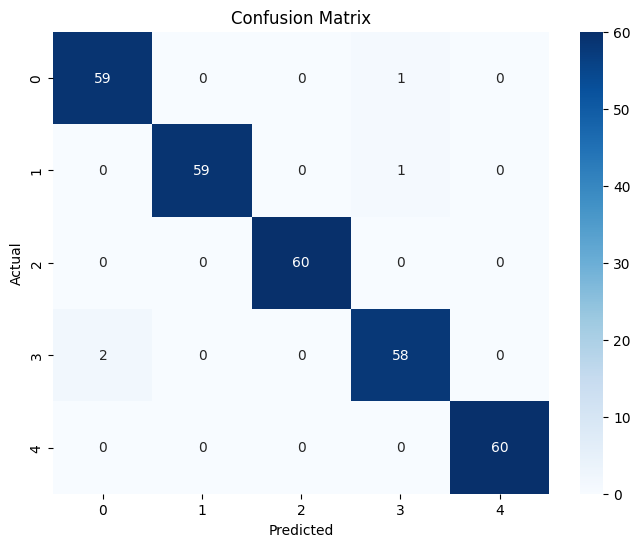

              precision    recall  f1-score   support

           0       0.97      0.98      0.98        60
           1       1.00      0.98      0.99        60
           2       1.00      1.00      1.00        60
           3       0.97      0.97      0.97        60
           4       1.00      1.00      1.00        60

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [11]:
# Confusion Matrix

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred_classes))

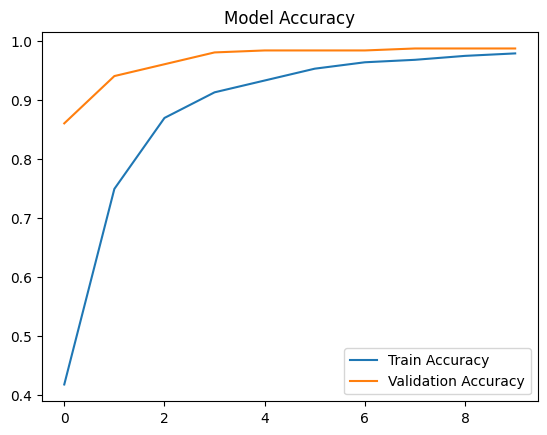

In [12]:
# Training Graph

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [13]:
# Save Model

model.save("leukemia_model.h5")

In [14]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [15]:
class_names = ['ALL', 'AML', 'CLL', 'CML', 'Healthy']

In [16]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        predicted_class = tf.argmax(predictions[0])
        loss = predictions[:, predicted_class]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [17]:
for layer in model.layers:
    print(layer.name)

input_layer
Conv1
bn_Conv1
Conv1_relu
expanded_conv_depthwise
expanded_conv_depthwise_BN
expanded_conv_depthwise_relu
expanded_conv_project
expanded_conv_project_BN
block_1_expand
block_1_expand_BN
block_1_expand_relu
block_1_pad
block_1_depthwise
block_1_depthwise_BN
block_1_depthwise_relu
block_1_project
block_1_project_BN
block_2_expand
block_2_expand_BN
block_2_expand_relu
block_2_depthwise
block_2_depthwise_BN
block_2_depthwise_relu
block_2_project
block_2_project_BN
block_2_add
block_3_expand
block_3_expand_BN
block_3_expand_relu
block_3_pad
block_3_depthwise
block_3_depthwise_BN
block_3_depthwise_relu
block_3_project
block_3_project_BN
block_4_expand
block_4_expand_BN
block_4_expand_relu
block_4_depthwise
block_4_depthwise_BN
block_4_depthwise_relu
block_4_project
block_4_project_BN
block_4_add
block_5_expand
block_5_expand_BN
block_5_expand_relu
block_5_depthwise
block_5_depthwise_BN
block_5_depthwise_relu
block_5_project
block_5_project_BN
block_5_add
block_6_expand
block_6_ex

In [18]:
import os

folder = "/content/dataset/ALL"
img_name = os.listdir(folder)[0]   # picks first image
img_path = os.path.join(folder, img_name)

print("Using image:", img_path)

img = cv2.imread(img_path)

if img is None:
    print("Image not loaded")
else:
    print("Image loaded")

img = cv2.resize(img, (224, 224))
img_array = np.expand_dims(img / 255.0, axis=0)

Using image: /content/dataset/ALL/TEST 20 744_original_20190114_144555.jpg_c3330c8e-3443-4636-b84d-39385ae13d7f.jpg
Image loaded


In [19]:
heatmap = get_gradcam_heatmap(model, img_array, "Conv_1")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


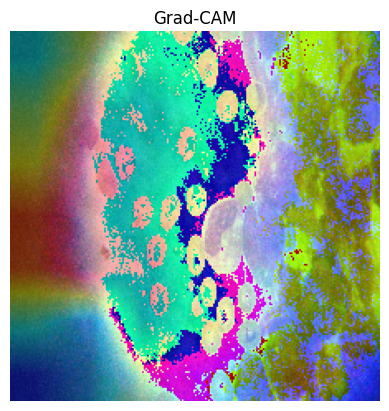

In [20]:
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Grad-CAM")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


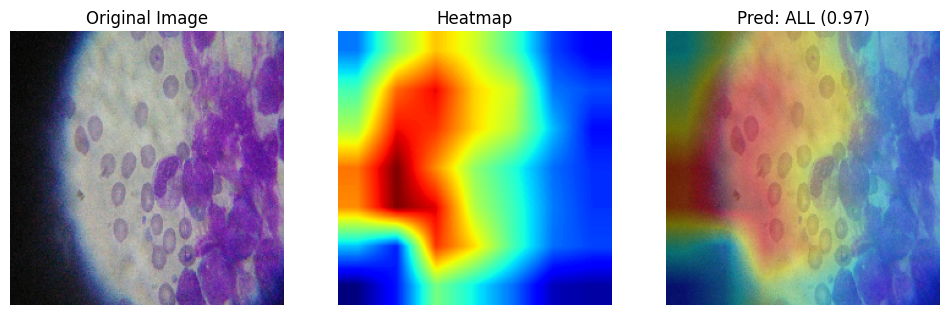

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# Class names (IMPORTANT)
class_names = ['ALL', 'AML', 'CLL', 'CML', 'Healthy']

# Pick image automatically
folder = "/content/dataset/ALL"
img_name = os.listdir(folder)[0]
img_path = os.path.join(folder, img_name)

# Load image
img = cv2.imread(img_path)
img_resized = cv2.resize(img, (224, 224))
img_array = np.expand_dims(img_resized / 255.0, axis=0)

# Prediction
pred = model.predict(img_array)
pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

# Grad-CAM heatmap
heatmap = get_gradcam_heatmap(model, img_array, "Conv_1")

# Process heatmap
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Overlay
overlay = cv2.addWeighted(img_resized, 0.6, heatmap_color, 0.4, 0)

# Convert BGR → RGB for plotting
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
overlay_rgb = cv2.cvtColor(overlay.astype('uint8'), cv2.COLOR_BGR2RGB)

# Plot everything
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Heatmap")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(overlay_rgb)
plt.title(f"Pred: {pred_class} ({confidence:.2f})")
plt.axis('off')

plt.show()

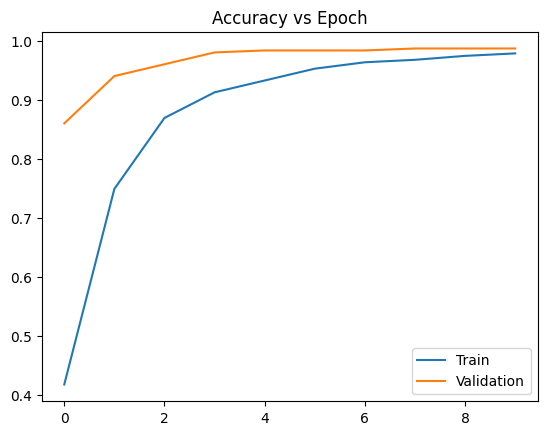

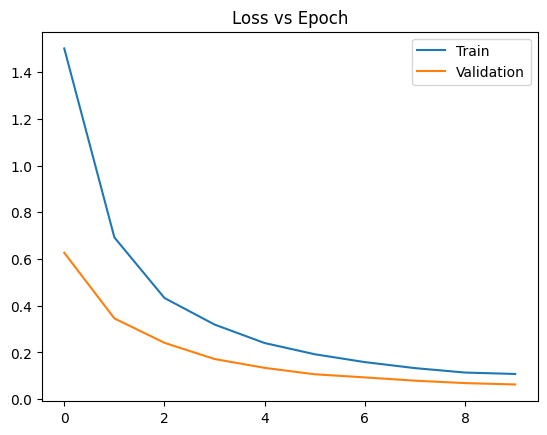

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy vs Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs Epoch')
plt.legend(['Train', 'Validation'])
plt.show()